In [13]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
from pandas.plotting import scatter_matrix
import seaborn as sns
import numpy as np

In [2]:
data=pd.read_csv(r"D:\ML Project\Data.csv",)
print(data)

               ra        dec         u         g         r         i  \
0      184.950869   0.733068  18.87062  17.59612  17.11245  16.83899   
1      185.729201   0.679704  19.59560  19.92153  20.34448  20.66213   
2      185.687690   0.823480  19.26421  17.87891  17.09593  16.65159   
3      185.677904   0.768362  19.49739  17.96166  17.41269  17.20545   
4      185.814763   0.776940  18.31519  16.83033  16.26352  16.06320   
...           ...        ...       ...       ...       ...       ...   
99995  154.077143  55.614066  19.39861  18.35476  18.00348  17.89408   
99996  154.067926  55.635794  19.07703  18.05159  17.78332  17.68976   
99997  153.897018  55.712582  19.07982  17.51349  16.64037  16.24183   
99998  235.656141  56.297044  17.27528  16.41704  16.11662  15.98858   
99999  235.821749  56.400331  17.90598  16.86471  16.51673  16.35695   

              z  petroRad_u  petroRad_g  petroRad_i  ...  psfMag_g  psfMag_i  \
0      16.70908    7.282402    7.004576    6.855976  ..

In [8]:
###################### CHECK MISSING DATA ##########################################

missing_count=data.isnull()

# isnull() checks every single cell in your DataFrame and returns another Dataframe with:
# True → if the cell value is missing (NaN, None)
# False → if the cell value exists

total_missing_count=missing_count.sum()

# We can use .sum() in both Dataframes and Series
# In .sum(), default axis=0, so it keeps column fizxed and adds row values together 
# (Basically this gives us the count of how many total missing values are there in each feature column)
# Returns a Series object

print(total_missing_count)

ra             0
dec            0
u              0
g              0
r              0
i              0
z              0
petroRad_u     0
petroRad_g     0
petroRad_i     0
petroRad_r     0
petroRad_z     0
petroFlux_u    0
petroFlux_g    0
petroFlux_i    0
petroFlux_r    0
petroFlux_z    0
petroR50_u     0
petroR50_g     0
petroR50_i     0
petroR50_r     0
petroR50_z     0
psfMag_u       0
psfMag_r       0
psfMag_g       0
psfMag_i       0
psfMag_z       0
expAB_u        0
expAB_g        0
expAB_r        0
expAB_i        0
expAB_z        0
redshift       0
class          0
dtype: int64


In [9]:
###################### CHECK DUPLICATE DATA ##########################################

duplicate=data.duplicated()
# Returns a Series, where each row is marked as True or False.
# If its True, then its a Duplicate row, otherwise its not a Duplicate Row

duplicate_sum=duplicate.sum()

print(duplicate_sum)

0


In [10]:
###################### CHECK DATA TYPES OF ROWS AND COLUMNS ##########################################

data_types=data.dtypes

# .dtypes() gives a series where the data type of the data contained in each column is mentioned

print(data_types)

ra             float64
dec            float64
u              float64
g              float64
r              float64
i              float64
z              float64
petroRad_u     float64
petroRad_g     float64
petroRad_i     float64
petroRad_r     float64
petroRad_z     float64
petroFlux_u    float64
petroFlux_g    float64
petroFlux_i    float64
petroFlux_r    float64
petroFlux_z    float64
petroR50_u     float64
petroR50_g     float64
petroR50_i     float64
petroR50_r     float64
petroR50_z     float64
psfMag_u       float64
psfMag_r       float64
psfMag_g       float64
psfMag_i       float64
psfMag_z       float64
expAB_u        float64
expAB_g        float64
expAB_r        float64
expAB_i        float64
expAB_z        float64
redshift       float64
class              str
dtype: object


In [11]:
######################## Univariate Analysis ##########################################

mean=data.mean(numeric_only=True)
mode=data.mode(numeric_only=True)
median=data.median(numeric_only=True)

In [13]:
print(mean)   # We can do normalization, but since we are gonna use Decision Trees/Boosting Algorithms, we are gonna prevent it for now

ra             168.856657
dec             17.832739
u               18.641137
g               17.407088
r               16.878550
i               16.517137
z               16.154837
petroRad_u       6.497004
petroRad_g       4.678636
petroRad_i       4.458623
petroRad_r       4.478506
petroRad_z       4.560777
petroFlux_u     52.988780
petroFlux_g    175.000342
petroFlux_i    397.383205
petroFlux_r    302.745181
petroFlux_z    471.129084
petroR50_u      -3.683850
petroR50_g       1.111468
petroR50_i      -1.741663
petroR50_r       1.123442
petroR50_z      -8.957856
psfMag_u        19.592174
psfMag_r        17.884605
psfMag_g        18.392280
psfMag_i        17.531364
psfMag_z        17.138493
expAB_u          0.588445
expAB_g          0.673314
expAB_r          0.660934
expAB_i          0.549130
expAB_z          0.311389
redshift         0.168441
dtype: float64


In [14]:
print(mode)

            ra       dec         u         g         r         i        z  \
0    31.891871  13.56414  19.22439  17.91719  16.63373  15.92978  16.5112   
1   129.833740       NaN  19.24760       NaN  16.63773  16.17318      NaN   
2          NaN       NaN  19.49442       NaN  16.89665  17.13050      NaN   
3          NaN       NaN  19.49932       NaN  17.30029  17.21656      NaN   
4          NaN       NaN       NaN       NaN  17.38058  17.31184      NaN   
5          NaN       NaN       NaN       NaN       NaN       NaN      NaN   
6          NaN       NaN       NaN       NaN       NaN       NaN      NaN   
7          NaN       NaN       NaN       NaN       NaN       NaN      NaN   
8          NaN       NaN       NaN       NaN       NaN       NaN      NaN   
9          NaN       NaN       NaN       NaN       NaN       NaN      NaN   
10         NaN       NaN       NaN       NaN       NaN       NaN      NaN   
11         NaN       NaN       NaN       NaN       NaN       NaN      NaN   

In [15]:
print(median)

ra             168.079889
dec              2.899490
u               18.878005
g               17.520310
r               16.896065
i               16.594740
z               16.419040
petroRad_u       3.473864
petroRad_g       3.336594
petroRad_i       3.349003
petroRad_r       3.291405
petroRad_z       3.541550
petroFlux_u     27.950255
petroFlux_g     93.950580
petroFlux_i    214.238300
petroFlux_r    164.623100
petroFlux_z    243.603200
petroR50_u       1.468786
petroR50_g       1.546289
petroR50_i       1.497291
petroR50_r       1.537168
petroR50_z       1.469153
psfMag_u        19.560930
psfMag_r        18.023495
psfMag_g        18.585375
psfMag_i        17.742665
psfMag_z        17.526325
expAB_u          0.611638
expAB_g          0.704848
expAB_r          0.692239
expAB_i          0.679104
expAB_z          0.641443
redshift         0.048772
dtype: float64


In [ ]:
###################### Class Imablance ########################

class_series=data['class']

class_series.value_counts()

class
GALAXY    0.52343
STAR      0.37232
QSO       0.10425
Name: proportion, dtype: float64

In [ ]:
class_series.value_counts(normalize=True)    # Moderate Class imabalance exists

class
GALAXY    0.52343
STAR      0.37232
QSO       0.10425
Name: proportion, dtype: float64

## Paramater Correlation Analysis (Bivariate Analysis)

In [9]:
scaler=StandardScaler().set_output(transform="pandas")   # Retains pandas df object structure on output instead of numpy array (which allows retaining of headers)

parameter_set=data.drop(columns=["class"])

parameter_set_scaled=scaler.fit_transform(parameter_set)

parameter_corr=parameter_set_scaled.corr()

parameter_set_scaled

,ra,dec,u,g,r,i,z,petroRad_u,petroRad_g,petroRad_i,...,psfMag_r,psfMag_g,psfMag_i,psfMag_z,expAB_u,expAB_g,expAB_r,expAB_i,expAB_z,redshift
0,0.191955,-0.649093,0.276809,0.193943,0.209053,0.010155,0.010101,0.059798,0.457801,0.461930,...,1.256183,1.225043,0.054260,0.034875,-0.420702,-0.657970,-0.578203,-0.001285,0.003242,-0.291861
1,0.201238,-0.651119,1.151301,2.579767,3.097754,0.130780,0.080938,-0.392994,-0.660858,-0.634205,...,1.909382,1.194364,0.098545,0.062602,-0.055819,-0.601683,-1.061484,0.014254,-0.002226,-0.389736
2,0.200743,-0.645661,0.751569,0.484080,0.194288,0.004242,0.003617,-0.199646,-0.143017,-0.086932,...,0.515093,0.736138,0.020041,0.011844,0.435304,0.297781,0.452662,0.007258,0.007767,-0.127503
3,0.200626,-0.647753,1.032837,0.568980,0.477399,0.021717,0.017511,-0.399375,-0.659935,-0.632322,...,-0.358458,-0.335662,-0.009959,-0.000270,1.581619,0.486353,0.348572,-0.004725,0.012320,-0.387660
4,0.202258,-0.647428,-0.393166,-0.591742,-0.549698,-0.014322,-0.003273,-0.390678,-0.657808,-0.635254,...,-1.240793,-1.201653,-0.045696,-0.020985,1.581532,0.684765,0.257657,0.005159,0.003938,-0.387819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,-0.176274,1.434156,0.913686,0.972293,1.005431,0.043444,0.030205,0.250138,-0.637867,-0.617620,...,0.100979,-0.026220,0.011757,0.012508,1.580986,1.387398,0.549887,0.008006,0.004137,-0.388093
99996,-0.176384,1.434981,0.525787,0.661247,0.808658,0.036998,0.027469,-0.384441,-0.631749,-0.616995,...,-0.067732,-0.257524,0.005239,0.009687,0.822628,1.387916,1.394836,0.014248,0.004253,-0.388670
99997,-0.178423,1.437895,0.529152,0.109167,-0.212879,-0.008686,-0.004429,-0.025937,0.158588,0.095305,...,0.204352,0.514689,0.008282,0.004789,1.040295,0.369286,0.445070,0.007058,0.009757,-0.117297
99998,0.796713,1.460081,-1.647535,-1.015769,-0.680993,-0.016677,-0.003233,-0.376431,-0.632000,-0.615517,...,-1.382039,-1.531063,-0.048890,-0.021129,0.256045,-2.012267,-0.740612,0.003190,0.009338,-0.388781


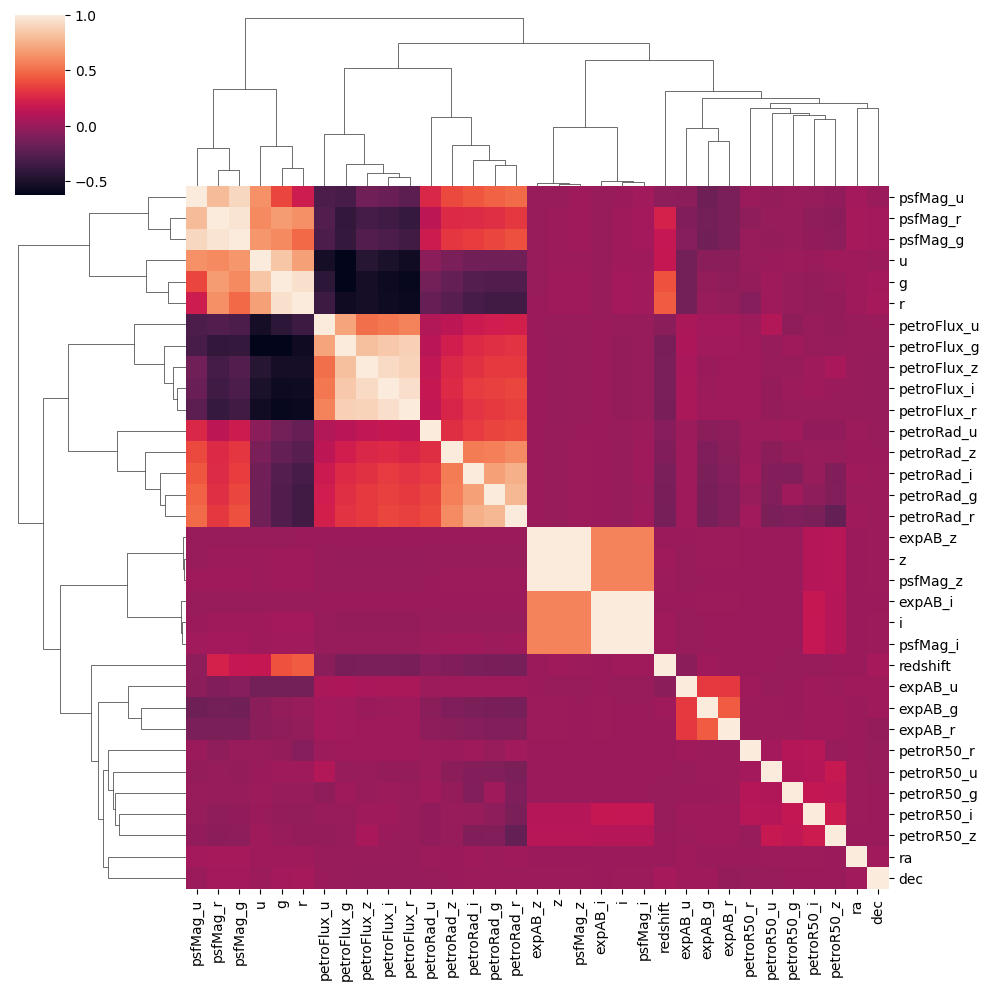

In [12]:
sns.clustermap(parameter_corr)

### Define new Dataset with dropped redundant parameters

In [14]:
corr = parameter_set.corr().abs()

# Keep only upper triangle
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

# Highly correlated pairs
high_corr = (
    upper
    .stack()
    .reset_index()
)

high_corr.columns = ['Feature_1', 'Feature_2', 'Correlation']

high_corr = high_corr[
    high_corr['Correlation'] > 0.9
]

print(high_corr)
print("Number of highly correlated pairs:",
      len(high_corr))

       Feature_1    Feature_2  Correlation
103            g            r     0.955252
190            i     psfMag_i     0.999436
195            i      expAB_i     0.999249
224            z     psfMag_z     0.999824
229            z      expAB_z     0.999699
477  petroFlux_i  petroFlux_r     0.947490
478  petroFlux_i  petroFlux_z     0.929760
750     psfMag_u     psfMag_g     0.913943
783     psfMag_r     psfMag_g     0.964144
855     psfMag_i      expAB_i     0.999127
889     psfMag_z      expAB_z     0.999707
Number of highly correlated pairs: 11


In [22]:
data_feature_engineered=data.drop(columns=['g','i','expAB_i','z','expAB_z','petroFlux_i','psfMag_g'])

In [23]:
data_feature_engineered.to_csv(r'D:\ML Project\Dataset Creation +EDA+Preprocessing\Data_Feature_Engineered.csv')